In [1]:
library(Seurat)
library(dplyr)
library(ggplot2)
library(patchwork)
library(RColorBrewer)
library(Nebulosa)
library(pheatmap)

root <- "/Users/fupac/Desktop/DECODER单细胞/figure2/Affirmseq_mouselung"
lung <- readRDS(file.path(root, "Affirmseq_mouselung.rds"))
top20 <- lung@misc$top20_markers
avg <- lung@misc$avg_expression


Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




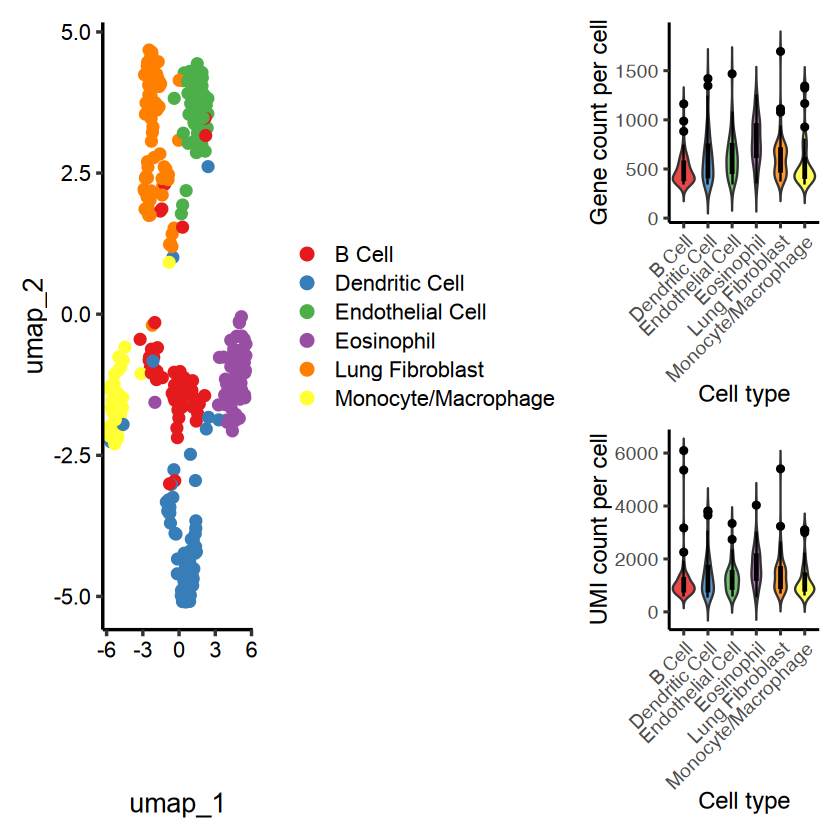

In [2]:
theme_lung <- theme_classic(base_size = 16) + theme(text = element_text(family = "Arial", color = "black"), axis.text = element_text(color = "black"), axis.title = element_text(color = "black"), legend.text = element_text(color = "black"), legend.title = element_text(color = "black"), plot.title = element_blank())
p_umap <- DimPlot(lung, reduction = "umap", group.by = "cell_type", pt.size = 2.5) + scale_color_brewer(palette = "Set1") + theme_lung
df <- lung@meta.data %>% select(cell_type, nFeature_RNA, nCount_RNA) %>% filter(!is.na(cell_type))
p_gene <- ggplot(df, aes(cell_type, nFeature_RNA, fill = cell_type)) + geom_violin(trim = FALSE, alpha = 0.8) + geom_boxplot(width = 0.1, color = "black") + scale_fill_brewer(palette = "Set1") + labs(y = "Gene count per cell", x = "Cell type") + theme_classic(base_size = 14) + theme(axis.text.x = element_text(angle = 45, hjust = 1), legend.position = "none")
p_umi <- ggplot(df, aes(cell_type, nCount_RNA, fill = cell_type)) + geom_violin(trim = FALSE, alpha = 0.8) + geom_boxplot(width = 0.1, color = "black") + scale_fill_brewer(palette = "Set1") + labs(y = "UMI count per cell", x = "Cell type") + theme_classic(base_size = 14) + theme(axis.text.x = element_text(angle = 45, hjust = 1), legend.position = "none")
p_overview <- p_umap | (p_gene / p_umi)
ggsave(file.path(root, "Affirmseq_mouselung_overview.pdf"), p_overview, width = 13, height = 6, device = cairo_pdf)
p_overview


Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


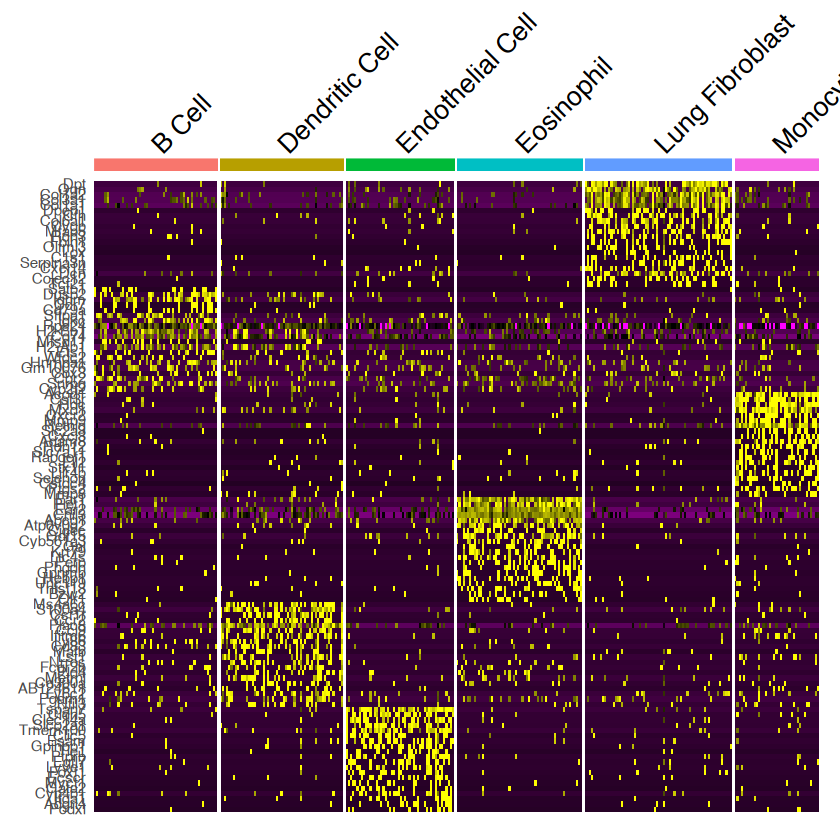

In [3]:
cols <- brewer.pal(length(unique(lung$cell_type)), "Set1")
names(cols) <- unique(lung$cell_type)
p_single <- DoHeatmap(lung, features = top20$gene, group.by = "cell_type", raster = FALSE) + NoLegend() + scale_color_manual(values = cols)
ggsave(file.path(root, "Affirmseq_mouselung_heatmap.pdf"), p_single, width = 8, height = 7, device = cairo_pdf)
ggsave(file.path(root, "Affirmseq_mouselung_doheatmap.pdf"), p_single, width = 8, height = 7, device = cairo_pdf)
p_single


agg_record_539550308 
                   2

agg_record_539550308 
                   2

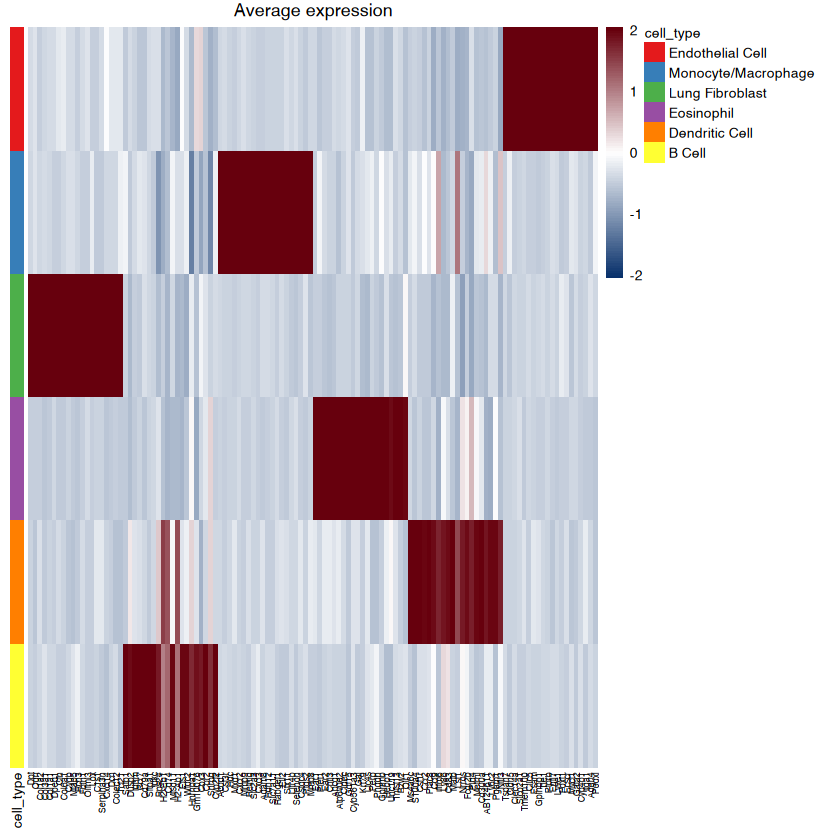

In [4]:
genes <- unique(top20$gene)
genes <- genes[genes %in% rownames(avg)]
mat <- t(avg[genes, , drop = FALSE])
ann <- data.frame(cell_type = rownames(mat))
rownames(ann) <- rownames(mat)
cols <- brewer.pal(length(unique(ann$cell_type)), "Set1")
names(cols) <- unique(ann$cell_type)
p_avg <- pheatmap(mat, cluster_rows = FALSE, cluster_cols = FALSE, scale = "column", color = colorRampPalette(c("#08306B", "white", "#67000D"))(100), annotation_row = ann, annotation_colors = list(cell_type = cols), show_rownames = FALSE, show_colnames = TRUE, angle_col = 90, treeheight_row = 0, treeheight_col = 0, fontsize = 8, fontsize_col = 5, border_color = "#BDBDBD", main = "Average expression", silent = TRUE)
pdf(file.path(root, "Affirmseq_mouselung_avg_expression_heatmap.pdf"), width = 10.5, height = 3.1)
grid::grid.draw(p_avg$gtable)
dev.off()
pdf(file.path(root, "Affirmseq_mouselung_panel_j_avg_expression_heatmap.pdf"), width = 10.5, height = 3.1)
grid::grid.draw(p_avg$gtable)
dev.off()
p_avg


Warning message:
“The `slot` argument of `FetchData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Nebulosa package.
  Please report the issue at
  <https://github.com/powellgenomicslab/Nebulosa/issues>.”


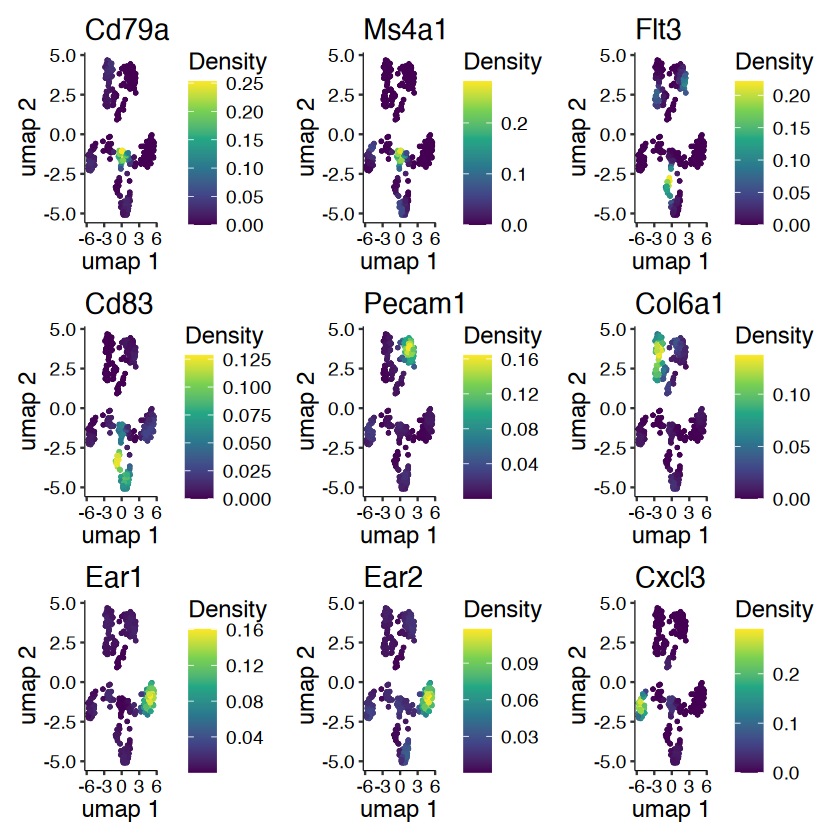

In [5]:
genes <- c("Cd79a", "Ms4a1", "Flt3", "Cd83", "Pecam1", "Col6a1", "Ear1", "Ear2", "Cxcl3")
genes <- genes[genes %in% rownames(lung)]
p_d <- plot_density(lung, genes, size = 1.2) + plot_layout(ncol = 3)
ggsave(file.path(root, "Affirmseq_mouselung_panel_d_density.pdf"), p_d, width = 8.8, height = 7.2, device = cairo_pdf)
p_d
